In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39763,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43319,Total threads: 4
Dashboard: http://127.0.0.1:37543/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:45915,


In [3]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [4]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [5]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251128_pinatubo10Tg19_e01/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20251128_Pinatubo10Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [6]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [7]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [8]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [9]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

In [11]:
path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

In [12]:
client.close()

In [13]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)

In [21]:
lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))

In [22]:
netlwtom = ds_19["FLNT"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netlwtom.sel(time=slice("1975-01", "1985-12"))
baseline = baseline.groupby("time.month").mean("time")
netlwtom_anom = netlwtom.groupby("time.month") - baseline
netlwtom_anom = netlwtom_anom.sel(time=slice("1991-01", "1996-01"))

In [23]:
netlwtom_19_c = ds_19_c["FLNT"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netlwtom_19_c_anom = netlwtom_19_c.groupby("time.month") - baseline

netlwtom_22 = ds_22["FLNT"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netlwtom_22_anom = netlwtom_22.groupby("time.month") - baseline

netlwtom_24 = ds_24["FLNT"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netlwtom_24_anom = netlwtom_24.groupby("time.month") - baseline

netlwtom_1825 = ds_1825["FLNT"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netlwtom_1825_anom = netlwtom_1825.groupby("time.month") - baseline

netlwtom_1825_17tg = ds_1825_17tg["FLNT"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netlwtom_1825_17tg_anom = netlwtom_1825_17tg.groupby("time.month") - baseline

netlwtom_1tg = ds_1tg["FLNT"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netlwtom_1tg_anom = netlwtom_1tg.groupby("time.month") - baseline

netlwtom_1pr = ds_1pr["FLNT"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netlwtom_1pr_anom = netlwtom_1pr.groupby("time.month") - baseline

netlwtom_60tg = ds_60tg["FLNT"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netlwtom_60tg_anom = netlwtom_60tg.groupby("time.month") - baseline

In [24]:
netswtom = ds_19["FSNT"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netswtom.sel(time=slice("1975-01", "1985-12"))
baseline = baseline.groupby("time.month").mean("time")
netswtom_anom = netswtom.groupby("time.month") - baseline
netswtom_anom = netswtom_anom.sel(time=slice("1991-01", "1996-01"))

In [25]:
netswtom_19_c = ds_19_c["FSNT"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netswtom_19_c_anom = netswtom_19_c.groupby("time.month") - baseline

netswtom_22 = ds_22["FSNT"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netswtom_22_anom = netswtom_22.groupby("time.month") - baseline

netswtom_24 = ds_24["FSNT"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netswtom_24_anom = netswtom_24.groupby("time.month") - baseline

netswtom_1825 = ds_1825["FSNT"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netswtom_1825_anom = netswtom_1825.groupby("time.month") - baseline

netswtom_1825_17tg = ds_1825_17tg["FSNT"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netswtom_1825_17tg_anom = netswtom_1825_17tg.groupby("time.month") - baseline

netswtom_1tg = ds_1tg["FSNT"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netswtom_1tg_anom = netswtom_1tg.groupby("time.month") - baseline

netswtom_1pr = ds_1pr["FSNT"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netswtom_1pr_anom = netswtom_1pr.groupby("time.month") - baseline

netswtom_60tg = ds_60tg["FSNT"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netswtom_60tg_anom = netswtom_60tg.groupby("time.month") - baseline

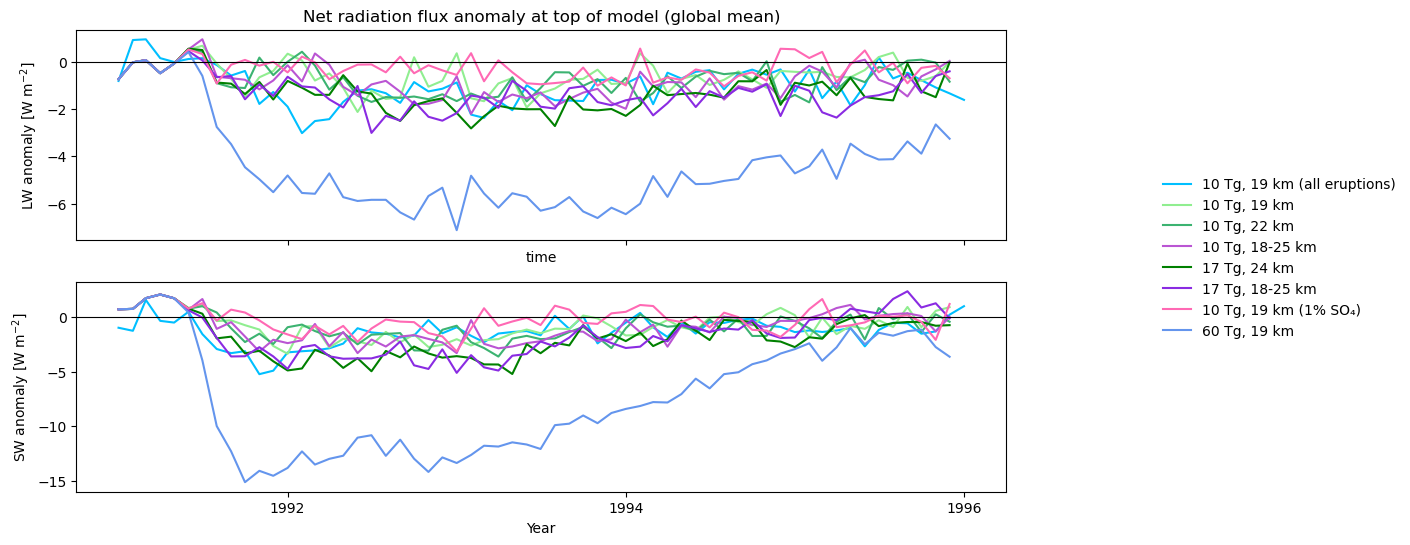

In [27]:
fig, (ax_lw, ax_sw) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True
)


netlwtom_anom.plot(
    ax=ax_lw,
    color="deepskyblue",
    lw=1.5,
    label="10 Tg, 19 km (all eruptions)"
)

ax_lw.plot(netlwtom_19_c_anom.time, netlwtom_19_c_anom,
           color="lightgreen", lw=1.5,
           label="10 Tg, 19 km")

ax_lw.plot(netlwtom_22_anom.time, netlwtom_22_anom,
           color="mediumseagreen", lw=1.5,
           label="10 Tg, 22 km")

ax_lw.plot(netlwtom_1825_anom.time, netlwtom_1825_anom,
           color="mediumorchid", lw=1.5,
           label="10 Tg, 18-25 km")

ax_lw.plot(netlwtom_24_anom.time, netlwtom_24_anom,
           color="green", lw=1.5,
           label="17 Tg, 24 km")

ax_lw.plot(netlwtom_1825_17tg_anom.time, netlwtom_1825_17tg_anom,
           color="blueviolet", lw=1.5,
           label="17 Tg, 18-25 km")

ax_lw.plot(netlwtom_1pr_anom.time, netlwtom_1pr_anom,
           color="hotpink", lw=1.5,
           label="10 Tg, 19 km (1% SO₄)")

ax_lw.plot(netlwtom_60tg_anom.time, netlwtom_60tg_anom,
           color="cornflowerblue", lw=1.5,
           label="60 Tg, 19 km")

ax_lw.axhline(0, color="black", lw=0.8)
ax_lw.set_ylabel("LW anomaly [W m$^{-2}$]")
ax_lw.set_title("Net radiation flux anomaly at top of model (global mean)")


ax_sw.plot(netswtom_anom.time, netswtom_anom,
           color="deepskyblue", lw=1.5)

ax_sw.plot(netswtom_19_c_anom.time, netswtom_19_c_anom,
           color="lightgreen", lw=1.5)

ax_sw.plot(netswtom_22_anom.time, netswtom_22_anom,
           color="mediumseagreen", lw=1.5)

ax_sw.plot(netswtom_1825_anom.time, netswtom_1825_anom,
           color="mediumorchid", lw=1.5)

ax_sw.plot(netswtom_24_anom.time, netswtom_24_anom,
           color="green", lw=1.5)

ax_sw.plot(netswtom_1825_17tg_anom.time, netswtom_1825_17tg_anom,
           color="blueviolet", lw=1.5)

ax_sw.plot(netswtom_1pr_anom.time, netswtom_1pr_anom,
           color="hotpink", lw=1.5)

ax_sw.plot(netswtom_60tg_anom.time, netswtom_60tg_anom,
           color="cornflowerblue", lw=1.5)

ax_sw.axhline(0, color="black", lw=0.8)
ax_sw.set_ylabel("SW anomaly [W m$^{-2}$]")
ax_sw.set_xlabel("Year")


fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)


plt.show()


In [28]:
netlwsurf = ds_19["FLNS"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netlwsurf.sel(time=slice("1975-01", "1985-12"))
baseline = baseline.groupby("time.month").mean("time")
netlwsurf_anom = netlwsurf.groupby("time.month") - baseline
netlwsurf_anom = netlwsurf_anom.sel(time=slice("1991-01", "1996-01"))

In [29]:
netlwsurf_19_c = ds_19_c["FLNS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netlwsurf_19_c_anom = netlwsurf_19_c.groupby("time.month") - baseline

netlwsurf_22 = ds_22["FLNS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netlwsurf_22_anom = netlwsurf_22.groupby("time.month") - baseline

netlwsurf_24 = ds_24["FLNS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netlwsurf_24_anom = netlwsurf_24.groupby("time.month") - baseline

netlwsurf_1825 = ds_1825["FLNS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netlwsurf_1825_anom = netlwsurf_1825.groupby("time.month") - baseline

netlwsurf_1825_17tg = ds_1825_17tg["FLNS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netlwsurf_1825_17tg_anom = netlwsurf_1825_17tg.groupby("time.month") - baseline

netlwsurf_1tg = ds_1tg["FLNS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netlwsurf_1tg_anom = netlwsurf_1tg.groupby("time.month") - baseline

netlwsurf_1pr = ds_1pr["FLNS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netlwsurf_1pr_anom = netlwsurf_1pr.groupby("time.month") - baseline

netlwsurf_60tg = ds_60tg["FLNS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netlwsurf_60tg_anom = netlwsurf_60tg.groupby("time.month") - baseline

In [30]:
netswsurf = ds_19["FSNS"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netswsurf.sel(time=slice("1975-01", "1985-12"))
baseline = baseline.groupby("time.month").mean("time")
netswsurf_anom = netswsurf.groupby("time.month") - baseline
netswsurf_anom = netswsurf_anom.sel(time=slice("1991-01", "1996-01"))

In [31]:
netswsurf_19_c = ds_19_c["FSNS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netswsurf_19_c_anom = netswsurf_19_c.groupby("time.month") - baseline

netswsurf_22 = ds_22["FSNS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netswsurf_22_anom = netswsurf_22.groupby("time.month") - baseline

netswsurf_24 = ds_24["FSNS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netswsurf_24_anom = netswsurf_24.groupby("time.month") - baseline

netswsurf_1825 = ds_1825["FSNS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netswsurf_1825_anom = netswsurf_1825.groupby("time.month") - baseline

netswsurf_1825_17tg = ds_1825_17tg["FSNS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netswsurf_1825_17tg_anom = netswsurf_1825_17tg.groupby("time.month") - baseline

netswsurf_1tg = ds_1tg["FSNS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netswsurf_1tg_anom = netswsurf_1tg.groupby("time.month") - baseline

netswsurf_1pr = ds_1pr["FSNS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netswsurf_1pr_anom = netswsurf_1pr.groupby("time.month") - baseline

netswsurf_60tg = ds_60tg["FSNS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netswsurf_60tg_anom = netswsurf_60tg.groupby("time.month") - baseline

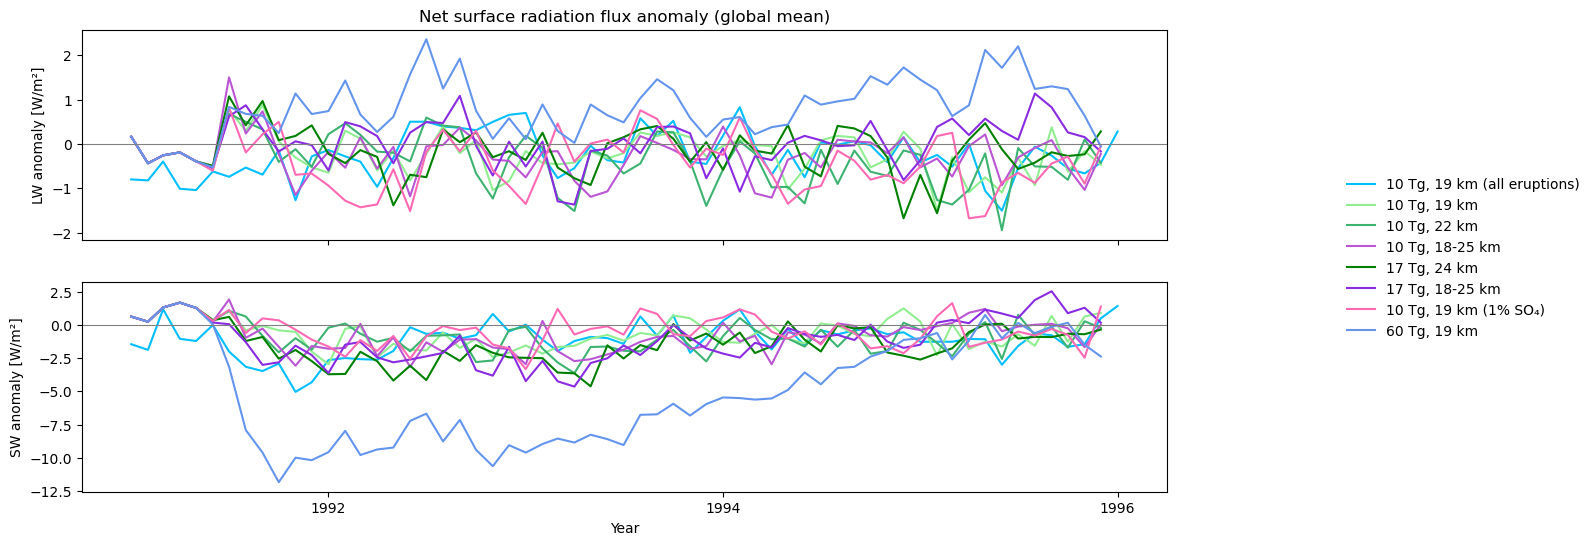

In [32]:
fig, (ax_lw, ax_sw) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)


ax_lw.plot(netlwsurf_anom.time, netlwsurf_anom, color="deepskyblue", lw=1.5,label="10 Tg, 19 km (all eruptions)")
ax_lw.plot(netlwsurf_19_c_anom.time, netlwsurf_19_c_anom, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax_lw.plot(netlwsurf_22_anom.time, netlwsurf_22_anom,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax_lw.plot(netlwsurf_1825_anom.time, netlwsurf_1825_anom,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax_lw.plot(netlwsurf_24_anom.time, netlwsurf_24_anom,color="green", lw=1.5,label="17 Tg, 24 km")
ax_lw.plot(netlwsurf_1825_17tg_anom.time, netlwsurf_1825_17tg_anom,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax_lw.plot(netlwsurf_1pr_anom.time, netlwsurf_1pr_anom,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax_lw.plot(netlwsurf_60tg_anom.time, netlwsurf_60tg_anom,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax_lw.axhline(0, color="gray", lw=0.8)
ax_lw.set_ylabel("LW anomaly [W/m²]")
ax_lw.set_title("Net surface radiation flux anomaly (global mean)")


ax_sw.plot(netswsurf_anom.time, netswsurf_anom,color="deepskyblue", lw=1.5)
ax_sw.plot(netswsurf_19_c_anom.time, netswsurf_19_c_anom,color="lightgreen", lw=1.5)
ax_sw.plot(netswsurf_22_anom.time, netswsurf_22_anom,color="mediumseagreen", lw=1.5)
ax_sw.plot(netswsurf_1825_anom.time, netswsurf_1825_anom,color="mediumorchid", lw=1.5)
ax_sw.plot(netswsurf_24_anom.time, netswsurf_24_anom,color="green", lw=1.5)
ax_sw.plot(netswsurf_1825_17tg_anom.time, netswsurf_1825_17tg_anom,color="blueviolet", lw=1.5)
ax_sw.plot(netswsurf_1pr_anom.time, netswsurf_1pr_anom,color="hotpink", lw=1.5)
ax_sw.plot(netswsurf_60tg_anom.time, netswsurf_60tg_anom,color="cornflowerblue", lw=1.5)
ax_sw.axhline(0, color="gray", lw=0.8)
ax_sw.set_ylabel("SW anomaly [W/m²]")
ax_sw.set_xlabel("Year")

fig.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()
